# Assignment 2: Transfer Learning Across Two Datasets

**Name:** *(Noah Reed)*

**Prerequisite:** Transfer Learning lecture (frozen feature extraction)

This assignment uses frozen transfer learning, exactly what was covered in lecture: load a pretrained base, freeze it, add a new head, train only that. You'll do this twice, on two different datasets, and compare the results.

Data loading is provided for you below. Everything after that, building the model, training, evaluating, and reflecting, is yours to write, following the general instructions in each section.

**Submission:** GitHub repo URL and this notebook's URL on Canvas.

## Setup — Imports

In [3]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

---
# Part 1: Fire/Smoke Detection

## 1A — Load the Data

In [4]:
!pip install legacy-cgi --quiet
!pip install opendatasets --quiet

import opendatasets as od
od.download("https://www.kaggle.com/datasets/phylake1337/fire-dataset")

for root, dirs, files in os.walk("fire-dataset"):
    print(root, "->", dirs[:5], f"({len(files)} files)")

Skipping, found downloaded files in "./fire-dataset" (use force=True to force download)
fire-dataset -> ['fire_dataset'] (0 files)
fire-dataset/fire_dataset -> ['fire_images', 'non_fire_images'] (0 files)
fire-dataset/fire_dataset/fire_images -> [] (755 files)
fire-dataset/fire_dataset/non_fire_images -> [] (244 files)


In [5]:
data_dir_fire = "fire-dataset/fire_dataset"

img_size = (224, 224)
batch_size = 32

train_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_fire = tf.data.experimental.cardinality(val_test_raw_fire)
test_raw_fire = val_test_raw_fire.take(val_test_batches_fire // 2)
val_raw_fire = val_test_raw_fire.skip(val_test_batches_fire // 2)

class_names_fire = train_raw_fire.class_names
print("Class names:", class_names_fire)

Found 999 files belonging to 2 classes.
Using 700 files for training.
Found 999 files belonging to 2 classes.
Using 299 files for validation.
Class names: ['fire_images', 'non_fire_images']


## 1B — Inspect the Data

Before doing anything else, take a real look at what you loaded. How many images does each class have? Is there anything about the data itself that might affect how you should split it, or how you should interpret your model's results later?

Write whatever code you need to answer this for yourself.



Class 'fire_images': 755 images
Class 'non_fire_images': 244 images


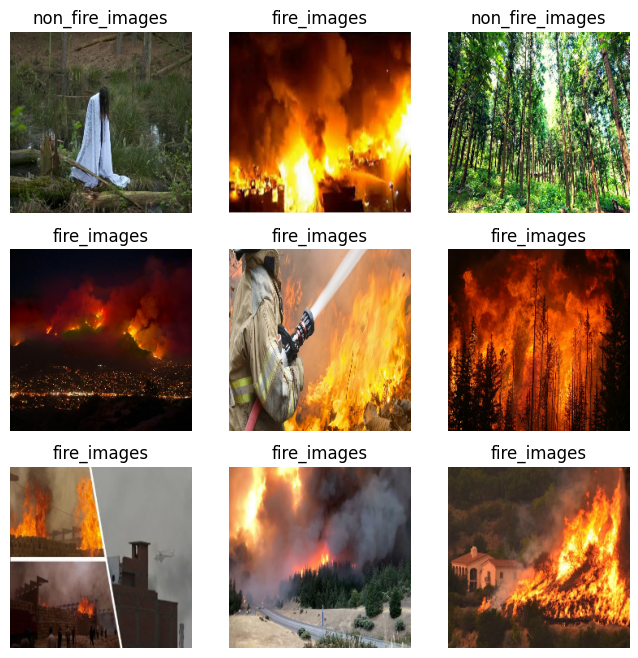

In [8]:
# Your exploration here

for class_name in os.listdir(data_dir_fire):
    class_path = os.path.join(data_dir_fire, class_name)
    if os.path.isdir(class_path):
        num_images = len(os.listdir(class_path))
        print(f"Class '{class_name}': {num_images} images")

plt.figure(figsize=(8, 8))
for images, labels in train_raw_fire.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names_fire[labels[i]])
        plt.axis("off")
plt.show()


*What did you notice about this dataset? Does it change how you'll approach the next steps?*

There are 755 fire images and 244 non fire images. This model has much more fire images than non fire images, so the model might have a tendency to predict 'fire' more often. Using a confusion matrix later will be critical to let me know how many images are being classified incorrectly.  



## 1C — Build a Frozen Transfer Learning Model

Using MobileNetV2 as your pretrained base:
- Freeze the base model entirely
- Add a new output layer appropriate for this task (think about how many classes you're predicting, and what that means for your output layer's size, activation, and loss function)
- Remember the pattern from lecture for how the base model should be called

Preprocess your data (`train_raw_fire`, `val_raw_fire`, `test_raw_fire`) using MobileNetV2's expected preprocessing before building your model.

In [10]:
# Preprocess the data here
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

def preprocess_mobilenet(image, label):
    return preprocess_input(image), label
train_ds_mobilenet = train_raw_fire.map(preprocess_mobilenet)
val_ds_mobilenet = val_raw_fire.map(preprocess_mobilenet)

# Preprocess test data (which contains both images and labels)
def preprocess_test_mobilenet(image, label):
    return preprocess_input(image), label

test_ds_mobilenet = test_raw_fire.map(preprocess_test_mobilenet)

In [11]:
# Build your model here
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model

# Build Transfer Learning Model (Frozen MobileNetV2)
base_model_mobilenet = MobileNetV2(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
base_model_mobilenet.trainable = False #freeze the base

# Freeze the base
x = base_model_mobilenet.output
x = GlobalAveragePooling2D()(x)

output = Dense(1, activation='sigmoid')(x)
mobilenet_model = Model(inputs=base_model_mobilenet.input, outputs=output)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [12]:
# Compile your model here
mobilenet_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
mobilenet_model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 1D — Train and Evaluate

In [13]:
# Train your model here
mobilenet_history = mobilenet_model.fit(
    train_ds_mobilenet,
    validation_data=val_ds_mobilenet,
    epochs=5
)


Epoch 1/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.8286 - loss: 0.3667 - val_accuracy: 0.9568 - val_loss: 0.2063
Epoch 2/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.9614 - loss: 0.1432 - val_accuracy: 0.9640 - val_loss: 0.1272
Epoch 3/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.9757 - loss: 0.1010 - val_accuracy: 0.9640 - val_loss: 0.0868
Epoch 4/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9786 - loss: 0.0826 - val_accuracy: 0.9856 - val_loss: 0.0687
Epoch 5/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.9829 - loss: 0.0713 - val_accuracy: 0.9928 - val_loss: 0.0641


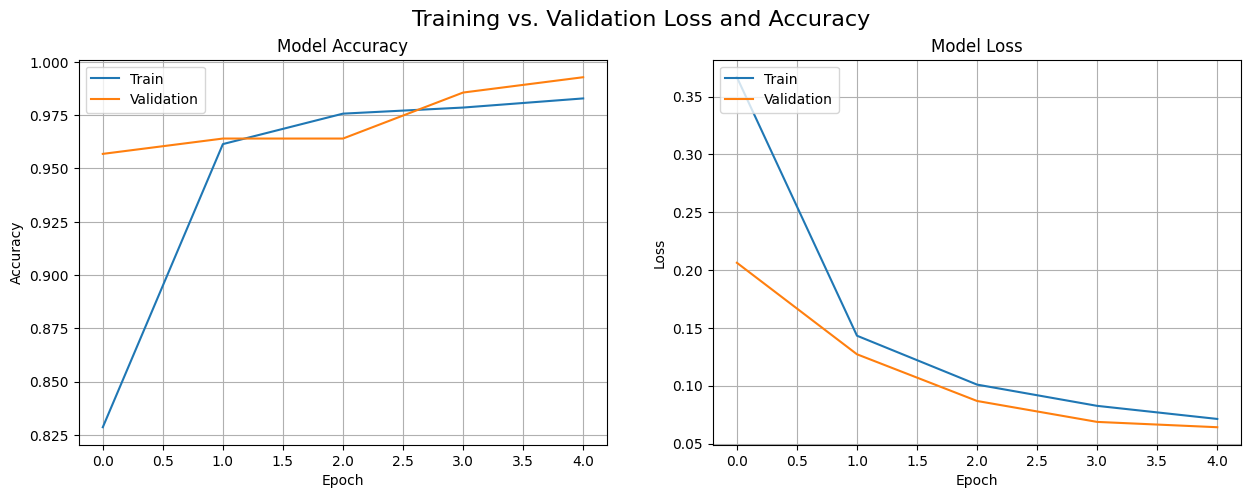

In [18]:
# Report validation and test accuracy here
import matplotlib.pyplot as plt

def plot_history(mobilenet_history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot training & validation accuracy values
    ax1.plot(mobilenet_history.history['accuracy'])
    ax1.plot(mobilenet_history.history['val_accuracy'])
    ax1.set_title('Model Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(['Train', 'Validation'], loc='upper left')
    ax1.grid(True)

    # Plot training & validation loss values
    ax2.plot(mobilenet_history.history['loss'])
    ax2.plot(mobilenet_history.history['val_loss'])
    ax2.set_title('Model Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(['Train', 'Validation'], loc='upper left')
    ax2.grid(True)

    fig.suptitle(title, fontsize=16)
    plt.show()

plot_history(mobilenet_history, "Training vs. Validation Loss and Accuracy")



## 1E — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** In this context, is a false negative (missing a real fire) or a false positive (a false alarm) more costly? How might that change the decision threshold you'd actually use in practice, rather than the default 0.5?

5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 832ms/step


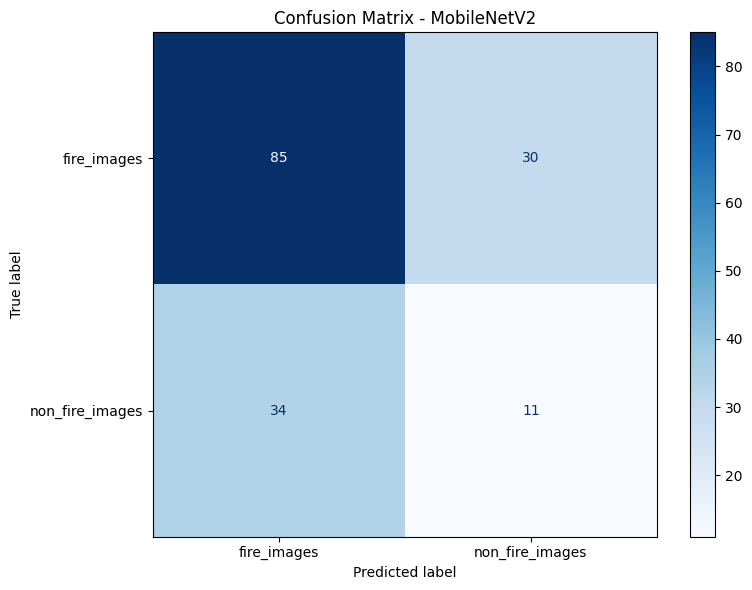

Test Loss: 0.0813
Test Accuracy: 0.9688


In [17]:
# Build your confusion matrix here
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# 1. Extract true labels from the test dataset
y_true = []
for _, labels in test_ds_mobilenet:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

# 2. Get predictions (probabilities) and convert to binary classes (0 or 1)
mobilenet_pred_probs = mobilenet_model.predict(test_ds_mobilenet)
y_pred = (mobilenet_pred_probs >= 0.5).astype(int).flatten()

# 3. Calculate confusion matrix
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names_fire)
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title("Confusion Matrix - MobileNetV2")
plt.tight_layout()
plt.show()

# Evaluate using the tf.data test pipeline
loss, accuracy = mobilenet_model.evaluate(test_ds_mobilenet, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

*Your answer:*
A model that predicts more false negatives is a much more serious issue, because it would not be reliable at detecting fires. This means lowering the threshold so the model is more sensitive to detecting fire images, since there are 3x as many fire images as non fire images.




---
# Part 2: Satellite Land-Use Classification (EuroSAT)

## 2A — Load the Data

In [19]:
!wget -q "https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip?download=1" -O EuroSAT_RGB.zip
!unzip -q EuroSAT_RGB.zip -d eurosat_data

data_dir_sat = "eurosat_data/EuroSAT_RGB"
print(os.listdir(data_dir_sat))

['PermanentCrop', 'Highway', 'Industrial', 'River', 'AnnualCrop', 'Pasture', 'HerbaceousVegetation', 'Residential', 'Forest', 'SeaLake']


Found 27000 files belonging to 10 classes.
Using 18900 files for training.
Found 27000 files belonging to 10 classes.
Using 8100 files for validation.
Class names: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Class 'PermanentCrop': 2500 images
Class 'Highway': 2500 images
Class 'Industrial': 2500 images
Class 'River': 2500 images
Class 'AnnualCrop': 3000 images
Class 'Pasture': 2000 images
Class 'HerbaceousVegetation': 3000 images
Class 'Residential': 3000 images
Class 'Forest': 3000 images
Class 'SeaLake': 3000 images


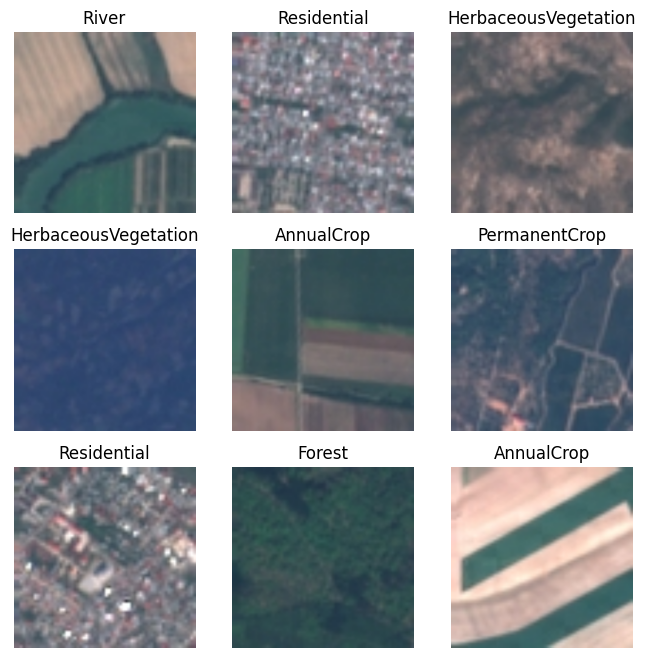

In [23]:
train_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_sat = tf.data.experimental.cardinality(val_test_raw_sat)
test_raw_sat = val_test_raw_sat.take(val_test_batches_sat // 2)
val_raw_sat = val_test_raw_sat.skip(val_test_batches_sat // 2)

class_names_sat = train_raw_sat.class_names
print("Class names:", class_names_sat)

for class_name in os.listdir(data_dir_sat):
    class_path = os.path.join(data_dir_sat, class_name)
    if os.path.isdir(class_path):
        num_images = len(os.listdir(class_path))
        print(f"Class '{class_name}': {num_images} images")

plt.figure(figsize=(8, 8))
for images, labels in train_raw_sat.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names_sat[labels[i]])
        plt.axis("off")
plt.show()


## 2B — Build a Frozen Transfer Learning Model

Same overall pattern as Part 1, but look closely at what's different about this task before you build your output layer, activation, and loss function.

Preprocess `train_raw_sat`, `val_raw_sat`, and `test_raw_sat` first.

In [25]:
# Preprocess the EuroSAT data here
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

def preprocess_mobilenet(image, label):
    return preprocess_input(image), label

# Using distinct variable names with a '_sat' suffix to avoid overwriting Part 1
train_ds_sat = train_raw_sat.map(preprocess_mobilenet)
val_ds_sat = val_raw_sat.map(preprocess_mobilenet)

def preprocess_test_mobilenet(image, label):
    return preprocess_input(image), label

test_ds_sat = test_raw_sat.map(preprocess_test_mobilenet)

In [26]:
# Build your model here
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model

# Build Transfer Learning Model (Frozen MobileNetV2) specifically for EuroSAT
base_model_sat = MobileNetV2(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
base_model_sat.trainable = False #freeze the base

x_sat = base_model_sat.output
x_sat = GlobalAveragePooling2D()(x_sat)

# EuroSAT has 10 classes, so we use activation='softmax' with len(class_names_sat) outputs
output_sat = Dense(len(class_names_sat), activation='softmax')(x_sat)
model_sat = Model(inputs=base_model_sat.input, outputs=output_sat)

In [28]:
# Compile your model here
model_sat.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_sat.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 2C — Train and Evaluate

In [29]:
# Train your model here
sat_history = model_sat.fit(
    train_ds_sat,
    validation_data=val_ds_sat,
    epochs=5
)


Epoch 1/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 572s 963ms/step - accuracy: 0.8775 - loss: 0.3792 - val_accuracy: 0.9291 - val_loss: 0.2234
Epoch 2/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 525s 888ms/step - accuracy: 0.9333 - loss: 0.1964 - val_accuracy: 0.9366 - val_loss: 0.1939
Epoch 3/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 620s 986ms/step - accuracy: 0.9470 - loss: 0.1605 - val_accuracy: 0.9400 - val_loss: 0.1843
Epoch 4/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 520s 880ms/step - accuracy: 0.9539 - loss: 0.1381 - val_accuracy: 0.9351 - val_loss: 0.1886
Epoch 5/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 562s 951ms/step - accuracy: 0.9587 - loss: 0.1243 - val_accuracy: 0.9316 - val_loss: 0.1976


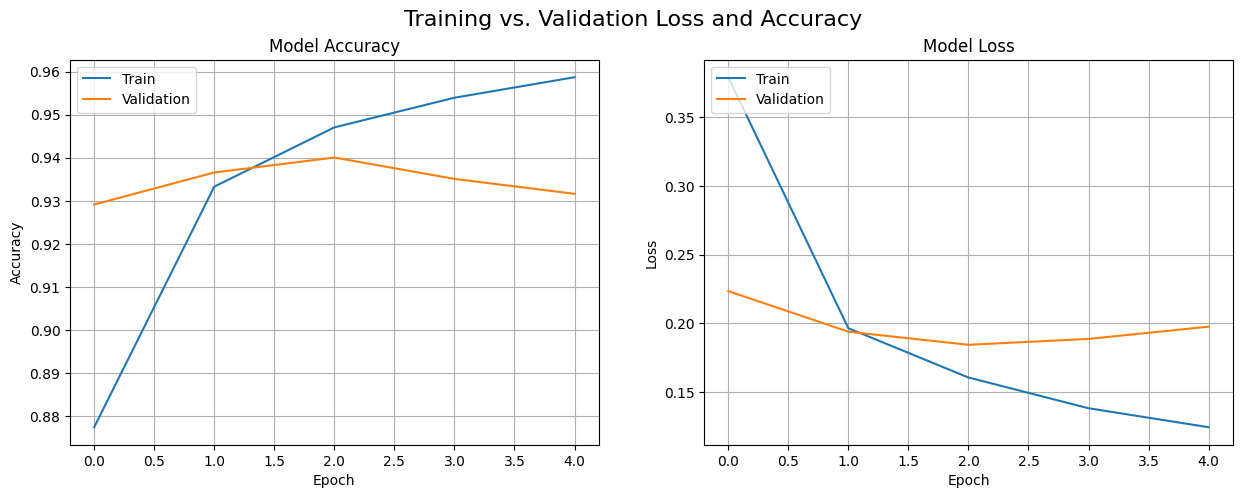

In [30]:
# Report validation and test accuracy here
import matplotlib.pyplot as plt

def plot_history(setattr_history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot training & validation accuracy values
    ax1.plot(sat_history.history['accuracy'])
    ax1.plot(sat_history.history['val_accuracy'])
    ax1.set_title('Model Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(['Train', 'Validation'], loc='upper left')
    ax1.grid(True)

    # Plot training & validation loss values
    ax2.plot(sat_history.history['loss'])
    ax2.plot(sat_history.history['val_loss'])
    ax2.set_title('Model Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(['Train', 'Validation'], loc='upper left')
    ax2.grid(True)

    fig.suptitle(title, fontsize=16)
    plt.show()

plot_history(sat_history, "Training vs. Validation Loss and Accuracy")



## 2D — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** Which land-use classes get confused most often? Does that make visual sense to you?

SeaLake was confused as AnnualCrop 62 times, this does make sense because from the satellite's point of view the dark forest green and dark water bodies can look similar in color.

127/127 ━━━━━━━━━━━━━━━━━━━━ 90s 711ms/step


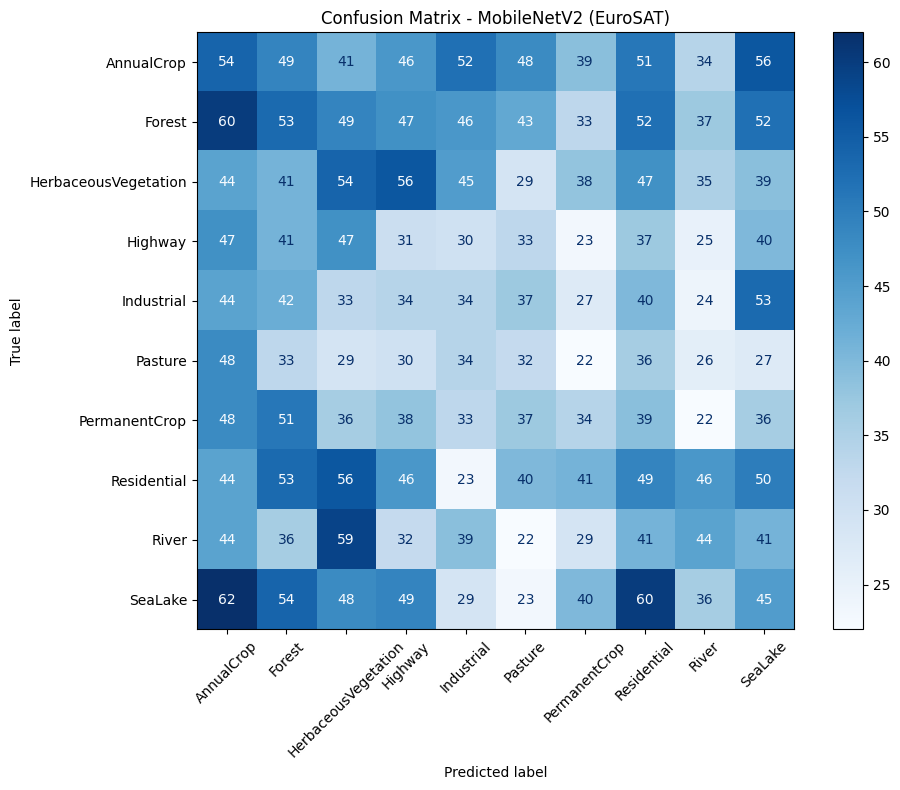

Test Loss: 0.1968
Test Accuracy: 0.9333


In [33]:
# Build your confusion matrix here
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# 1. Extract true labels from the test dataset
y_true1 = []
for _, labels in test_ds_sat:
    y_true1.extend(labels.numpy())
y_true1 = np.array(y_true1)

# 2. Get predictions (probabilities) and convert to class indices using argmax for multiclass
sat_pred_probs = model_sat.predict(test_ds_sat)
y_pred1 = np.argmax(sat_pred_probs, axis=1)

# 3. Calculate confusion matrix
cm = confusion_matrix(y_true1, y_pred1)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names_sat)
disp.plot(cmap='Blues', ax=ax, values_format='d', xticks_rotation=45)
plt.title("Confusion Matrix - MobileNetV2 (EuroSAT)")
plt.tight_layout()
plt.show()

# Evaluate using the tf.data test pipeline
loss, accuracy = model_sat.evaluate(test_ds_sat, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

*Your answer:*




---
# Part 3: Compare the Two Domains

Fill in your own results:

| | Fire/Smoke | EuroSAT |
|---|---|---|
| Validation Accuracy | 0.9928 | 0.9316 |
| Test Accuracy | 0.9688 | 0.9333 |

**Answer:**
1. MobileNetV2 was originally trained on ImageNet, ordinary ground-level photos of everyday objects. Which of your two datasets do you think is the closer match to that original training, and which is the bigger mismatch? Use your actual results as evidence.


2. For each dataset, do you think there's room for improvement if you could adjust part of the pretrained model itself, rather than just the new layer on top? Would you expect that to matter more for one dataset than the other? Why?


*Your answers:*
1. The fire dataset was a closer match because it consisted of ground level photos that are similar to ImageNet photos, and the model scored very well with a validation accuracy of 99.28% and test accuracy of 96.88% in 5 epochs. The EuroSAT dataset was a bigger mismatch because it had satellite images which look much different than the ImageNet objects.
2. Yes, there would be improvement for both datasets by unfreezing and fine-tuning the MobileNetV2 base model. The EuroSAT dataset would benefit much more because of the the style of images and ImageNet needs to be adjusted to see the structures similar to how EuroSAT sees them. Unfreezing MobileNetV2 and training with a lower learning rate would let it adapt better.



---
# Part 4: Reflection

Answer in 4 to 6 sentences:

1. Did anything about the Fire dataset's composition affect how you approached splitting or evaluating it? Explain.
2. What's the actual difference between the output layer, activation, and loss function you used in Part 1 versus Part 2? Why does that difference exist?
3. Based on your results, does a pretrained model's usefulness depend only on how good the model is, or also on how well its original training matches your task? Explain using your own two results as evidence.

*Your answers:*
1. Yes, because the fire dataset had a lot more fire images than non-fire images, it would be easy to have a high accuracy by just predicting the majority class so a confusion matrix was important to help determine if it was predicting accurately and not many false negatives.

2. In part 1 I used a sigmoid because it was binary and used binary_crossentropy loss. In part 2 I had to use softmax because it had 10 classes and used sparse_categorical_crossentropy loss.

3. It depends on how well its original training matches the task, because fire dataset worked well because it was similar to MobileNetV2 but the EuroSAT dataset was not as good, not because of the model, but because of how the images are different than what MobileNetV2 has.


---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.